<div style="border-top: 4px solid #b85300; border-bottom: 1px solid #b85300; padding: 40px 0 32px; margin-bottom: 8px;">
  <p style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:2px; margin:0 0 10px;">Lead University &nbsp;&middot;&nbsp; Minería de Datos I</p>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:2.3em; color:#000; margin:0 0 10px; font-weight:700; letter-spacing:0.3px;">Métodos No Supervisados</h1>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#444; margin:0; font-style:italic;">Reducción de Dimensionalidad &nbsp;&mdash;&nbsp; Fashion-MNIST · ropa.csv</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Configuración</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Librerías e Importaciones</h2>
</div>

In [1]:
%matplotlib inline
import pandas as pd
import importlib

import scripts.Dataset_1 as ropa

import warnings
warnings.filterwarnings('ignore')

c:\Users\borge\OneDrive\Documentos\DATA_SCIENCE\LEAD UNIVERSITY\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
  <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Dataset 1</span>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">ropa.csv</h1>
  <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Fashion-MNIST: 70 000 imágenes en escala de grises (28×28 píxeles) aplanadas a 784 variables numéricas. Cada fila corresponde a una prenda de vestir clasificada en 10 categorías. El objetivo es evaluar qué método de reducción de dimensionalidad separa mejor los 10 clusters de ropa en un espacio de baja dimensión.</p>
</div>

In [2]:
# Cargar ropa.csv
df1 = pd.read_csv('data/ropa.csv', index_col=0)

label_map = {  # Mapeo de etiquetas numéricas a nombres
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}
df1['label_name'] = df1['label'].map(label_map)

# Exploración básica
print('Shape:', df1.shape)
print('\nDistribución por clase:')
print(df1['label_name'].value_counts().sort_index())
print('\nValores nulos:', df1.isnull().sum().sum())
print('\nRango de píxeles:', df1.iloc[:, 1:-1].min().min(), '-', df1.iloc[:, 1:-1].max().max())

Shape: (1000, 786)

Distribución por clase:
label_name
Ankle boot     109
Bag            109
Coat            94
Dress           89
Pullover       111
Sandal          96
Shirt           91
Sneaker        102
T-shirt/top     89
Trouser        110
Name: count, dtype: int64

Valores nulos: 0

Rango de píxeles: 0 - 255


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 1</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Comparación 2D — ACP vs t-SNE vs UMAP</h2>
</div>

Varianza explicada por componente: [0.22308981 0.1486282 ]
Varianza explicada acumulada: 0.3717
Silhouette score (ACP): -0.0313
Silhouette score (t-SNE): 0.1454
Silhouette score por cantidad de vecinos: {5: 0.18374401330947876, 10: 0.17777051031589508, 15: 0.1931687891483307, 20: 0.16378970444202423, 30: 0.13885705173015594, 50: 0.12761187553405762}
Mejor cantidad de vecinos: 15 (silhouette score: 0.1932)


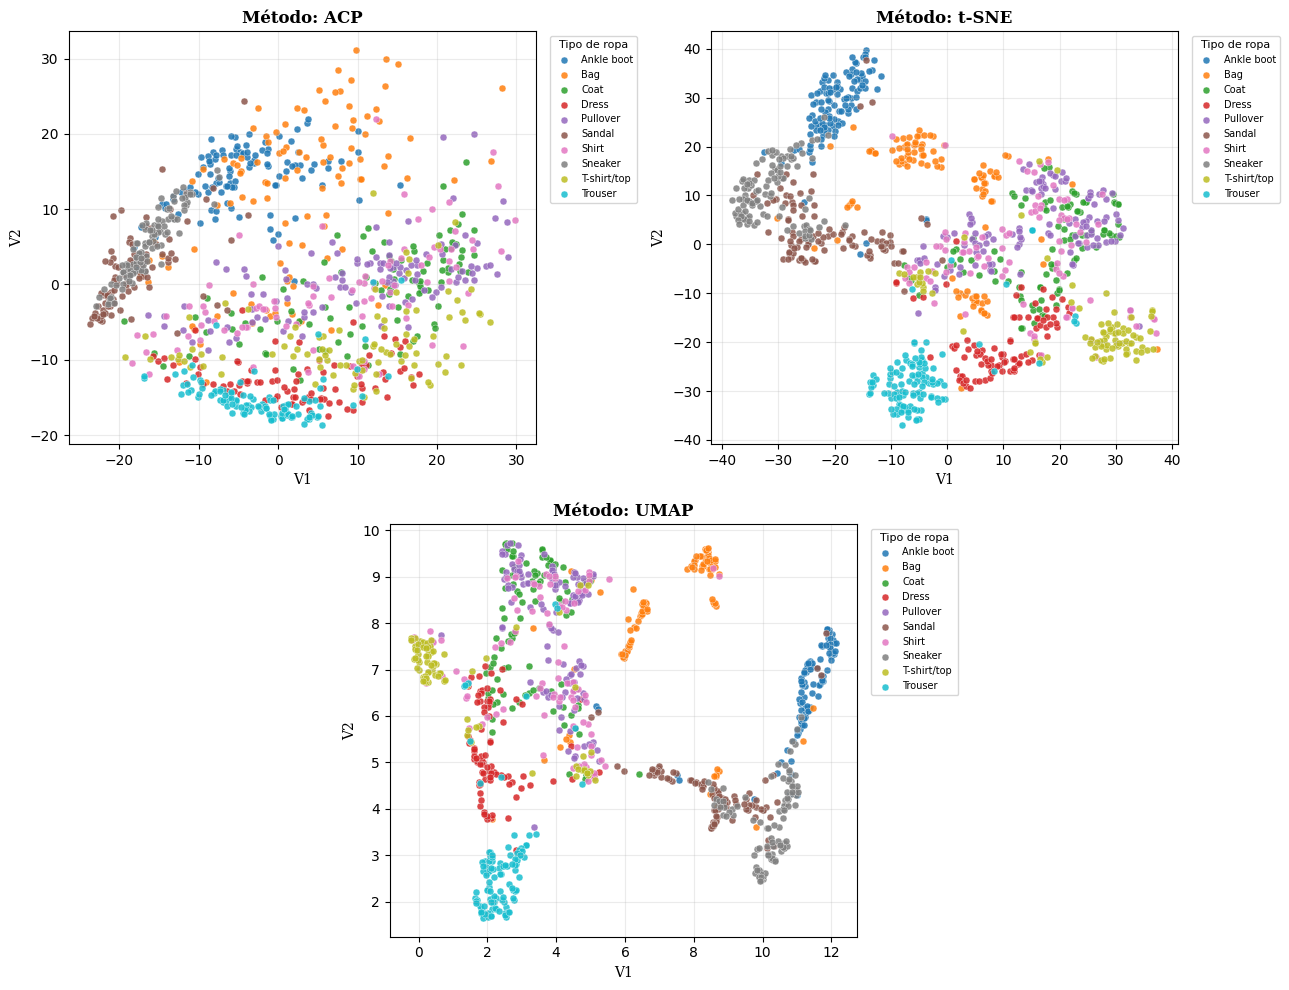

In [3]:
importlib.reload(ropa)
from scripts.Dataset_1 import acp, tsne, umap, graficar_comparacion

resultado_acp, modelo_acp = acp(df1, graficar=False)
resultado_tsne           = tsne(df1, graficar=False)
resultado_umap, mejor_n  = umap(df1, graficar=False)

graficar_comparacion(resultado_acp, resultado_tsne, resultado_umap)

<div style="margin: 24px 0; padding: 20px 24px; border: 1px solid #e0e0e0; border-left: 4px solid #b85300; background:#fafafa;">
  <p style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 8px;">Interpretación</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#000; font-weight:600; margin:0 0 12px;">¿Qué método separa mejor los 10 tipos de ropa en 2D?</p>
  <table style="width:100%; border-collapse:collapse; font-family:'Courier New', monospace; font-size:0.85em; margin-top:12px;">
  <thead>
    <tr style="border-bottom: 2px solid #b85300;">
      <th style="text-align:left; padding:6px 12px; color:#b85300;">#</th>
      <th style="text-align:left; padding:6px 12px; color:#b85300;">Método</th>
      <th style="text-align:left; padding:6px 12px; color:#b85300;">Silhouette Score</th>
      <th style="text-align:left; padding:6px 12px; color:#b85300;">Observación</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom:1px solid #ececec; background:#fff7f2;">
      <td style="padding:6px 12px; font-weight:700; color:#b85300;">1</td>
      <td style="padding:6px 12px; font-weight:600;">UMAP</td>
      <td style="padding:6px 12px;">0.1932</td>
      <td style="padding:6px 12px; color:#555;">Mejor separación · n_vecinos = 15</td>
    </tr>
    <tr style="border-bottom:1px solid #ececec; background:#ffffff;">
      <td style="padding:6px 12px; font-weight:700; color:#b85300;">2</td>
      <td style="padding:6px 12px; font-weight:600;">t-SNE</td>
      <td style="padding:6px 12px;">0.1454</td>
      <td style="padding:6px 12px; color:#555;">Separación moderada · relaciones no lineales</td>
    </tr>
    <tr style="border-bottom:1px solid #ececec; background:#ffffff;">
      <td style="padding:6px 12px; font-weight:700; color:#b85300;">3</td>
      <td style="padding:6px 12px; font-weight:600;">ACP</td>
      <td style="padding:6px 12px;">−0.0313</td>
      <td style="padding:6px 12px; color:#555;">Score negativo · solapamiento peor que al azar</td>
    </tr>
  </tbody>
</table><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">ACP captura solo el <strong>37.2%</strong> de la varianza total en 2 componentes. El 62.8% restante —donde reside la estructura discriminativa entre categorías— se descarta, produciendo un score negativo que indica que los clusters se solapan más de lo que ocurriría de forma aleatoria.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">t-SNE mejora notablemente al ser no lineal: captura relaciones entre píxeles que ACP ignora. Su score moderado refleja que preserva bien la estructura <em>local</em> pero distorsiona algo la <em>global</em>, dificultando la separación simultánea de los 10 tipos.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">UMAP es el ganador porque equilibra estructura local y global. Con <code>n_vecinos=15</code> encontró el balance óptimo entre el vecindario inmediato de cada punto y el panorama completo del espacio, logrando la mayor distancia inter-cluster.</p>
</div>

In [4]:
resultado_acp, modelo_acp = acp(df1, graficar=False)
resultado_tsne           = tsne(df1, graficar=False)
resultado_umap, mejor_n  = umap(df1, graficar=False)

Varianza explicada por componente: [0.22308981 0.1486282 ]
Varianza explicada acumulada: 0.3717
Silhouette score (ACP): -0.0313
Silhouette score (t-SNE): 0.1454
Silhouette score por cantidad de vecinos: {5: 0.18374401330947876, 10: 0.17777051031589508, 15: 0.1931687891483307, 20: 0.16378970444202423, 30: 0.13885705173015594, 50: 0.12761187553405762}
Mejor cantidad de vecinos: 15 (silhouette score: 0.1932)


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 2</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Comparación 3D — ACP vs t-SNE vs UMAP</h2>
</div>

Varianza explicada por componente: [0.22308981 0.1486282  0.05805916]
Varianza explicada acumulada: 0.4298
Silhouette score (ACP): 0.0097
Silhouette score (t-SNE): 0.1212
Silhouette score por cantidad de vecinos: {5: 0.18649640679359436, 10: 0.1759355515241623, 15: 0.16434377431869507, 20: 0.17182567715644836, 30: 0.15357302129268646, 50: 0.13680019974708557}
Mejor cantidad de vecinos: 5 (silhouette score: 0.1865)


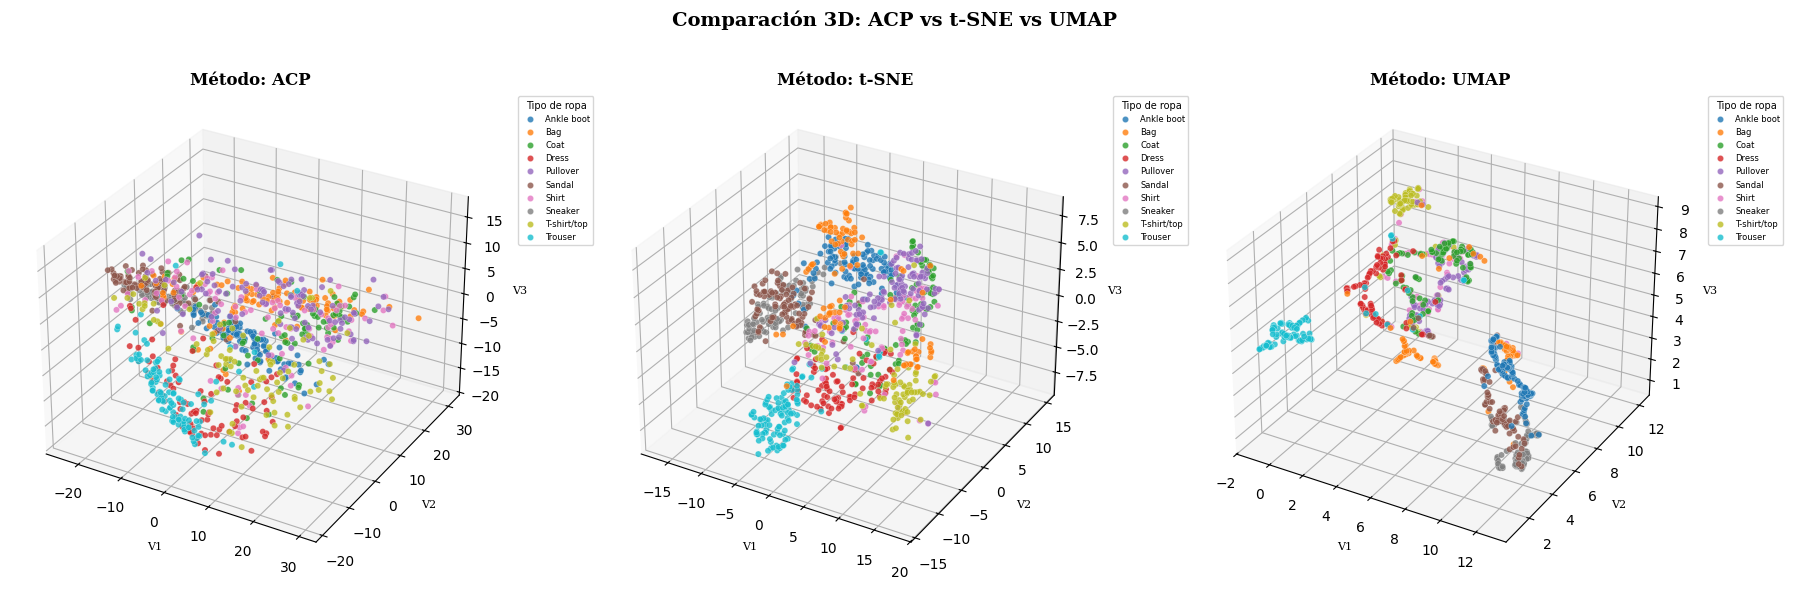

In [5]:
from scripts.Dataset_1 import acp, tsne, umap, graficar_comparacion_3d

resultado_acp_3d, modelo_acp_3d = acp(df1, n_components=3, graficar=False)
resultado_tsne_3d               = tsne(df1, n_components=3, graficar=False)
resultado_umap_3d, mejor_n      = umap(df1, n_components=3, graficar=False)

graficar_comparacion_3d(resultado_acp_3d, resultado_tsne_3d, resultado_umap_3d)

In [6]:
from sklearn.metrics import silhouette_score

print('ACP 3D:  ', silhouette_score(resultado_acp_3d.drop(columns='label_name'),  resultado_acp_3d['label_name']))
print('t-SNE 3D:', silhouette_score(resultado_tsne_3d.drop(columns='label_name'), resultado_tsne_3d['label_name']))
print('UMAP 3D: ', silhouette_score(resultado_umap_3d.drop(columns='label_name'), resultado_umap_3d['label_name']))

ACP 3D:   0.009704275279199207
t-SNE 3D: 0.1211627796292305
UMAP 3D:  0.18649640679359436


<div style="margin: 24px 0; padding: 20px 24px; border: 1px solid #e0e0e0; border-left: 4px solid #b85300; background:#fafafa;">
  <p style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 8px;">Interpretación</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#000; font-weight:600; margin:0 0 12px;">¿Qué método separa mejor los 10 tipos de ropa en 3D?</p>
  <table style="width:100%; border-collapse:collapse; font-family:'Courier New', monospace; font-size:0.85em; margin-top:12px;">
  <thead>
    <tr style="border-bottom: 2px solid #b85300;">
      <th style="text-align:left; padding:6px 12px; color:#b85300;">#</th>
      <th style="text-align:left; padding:6px 12px; color:#b85300;">Método</th>
      <th style="text-align:left; padding:6px 12px; color:#b85300;">Silhouette Score</th>
      <th style="text-align:left; padding:6px 12px; color:#b85300;">Observación</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom:1px solid #ececec; background:#fff7f2;">
      <td style="padding:6px 12px; font-weight:700; color:#b85300;">1</td>
      <td style="padding:6px 12px; font-weight:600;">UMAP</td>
      <td style="padding:6px 12px;">0.1865</td>
      <td style="padding:6px 12px; color:#555;">Mejor separación · leve descenso respecto a 2D</td>
    </tr>
    <tr style="border-bottom:1px solid #ececec; background:#ffffff;">
      <td style="padding:6px 12px; font-weight:700; color:#b85300;">2</td>
      <td style="padding:6px 12px; font-weight:600;">t-SNE</td>
      <td style="padding:6px 12px;">0.1211</td>
      <td style="padding:6px 12px; color:#555;">Baja con la dimensión extra · más distorsión local</td>
    </tr>
    <tr style="border-bottom:1px solid #ececec; background:#ffffff;">
      <td style="padding:6px 12px; font-weight:700; color:#b85300;">3</td>
      <td style="padding:6px 12px; font-weight:600;">ACP</td>
      <td style="padding:6px 12px;">0.0097</td>
      <td style="padding:6px 12px; color:#555;">Mejora desde −0.0313 · sigue siendo el peor</td>
    </tr>
  </tbody>
</table><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">El orden de los métodos se mantiene igual que en 2D. ACP mejora al pasar de −0.0313 a 0.0097 —la tercera componente captura algo de estructura útil— pero sigue siendo el peor método por un margen significativo.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">t-SNE baja de 0.1454 a 0.1211 en 3D. La dimensión extra introduce más distorsión local sin añadir suficiente información estructural para compensarla.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">UMAP baja levemente de 0.1932 a 0.1865: la mayor parte de la estructura discriminativa ya estaba capturada en 2 dimensiones. Añadir una tercera no aporta separación adicional significativa.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>Conclusión:</strong> Para datos de alta dimensionalidad con relaciones no lineales como Fashion-MNIST, los métodos no lineales superan claramente a ACP. UMAP resulta el más efectivo en ambas dimensionalidades, sugiriendo que 2D es suficiente para representar la estructura discriminativa del dataset.</p>
</div>

<hr style="border:none; border-top:1px solid #e0e0e0; margin:48px 0 0;">